In [ ]:
# here we import libraries that I needed to perform EDA and ML  

In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from scipy.stats import zscore
from sklearn.preprocessing import PowerTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix,accuracy_score,classification_report 
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
sns.set(style="whitegrid")
plt.rcParams['figure.dpi'] = 120

In [2]:
fear= pd.read_csv("fear_greed_index.csv")

In [3]:
trades=pd.read_csv("historical_data.csv")

In [4]:
fear.head()

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [5]:
trades.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


In [ ]:
# Here we check Shape. Where we find the number of rows and number of columns of both data sets 

In [6]:
print("Fear Shape:", fear.shape)
print("Trades Shape:", trades.shape)

Fear Shape: (2644, 4)
Trades Shape: (211224, 16)


In [ ]:
# Here we see the column names and both data sets. 

In [7]:
print("Fear Columns:", fear.columns)
print("Trades Columns:", trades.columns)

Fear Columns: Index(['timestamp', 'value', 'classification', 'date'], dtype='object')
Trades Columns: Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp'],
      dtype='object')


In [ ]:
# Here we check the data types of a fear data set. Here, the date column has an object data type.
# Its real data type is a date-time data type, so we can change it. 

In [8]:
fear.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2644 entries, 0 to 2643
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   timestamp       2644 non-null   int64 
 1   value           2644 non-null   int64 
 2   classification  2644 non-null   object
 3   date            2644 non-null   object
dtypes: int64(2), object(2)
memory usage: 82.8+ KB


In [ ]:
# Here we check the data types of a trades data set. 
# We find that the timestamp column has an object data type, but its real data type is date/time data type 

In [9]:
trades.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Account           211224 non-null  object 
 1   Coin              211224 non-null  object 
 2   Execution Price   211224 non-null  float64
 3   Size Tokens       211224 non-null  float64
 4   Size USD          211224 non-null  float64
 5   Side              211224 non-null  object 
 6   Timestamp IST     211224 non-null  object 
 7   Start Position    211224 non-null  float64
 8   Direction         211224 non-null  object 
 9   Closed PnL        211224 non-null  float64
 10  Transaction Hash  211224 non-null  object 
 11  Order ID          211224 non-null  int64  
 12  Crossed           211224 non-null  bool   
 13  Fee               211224 non-null  float64
 14  Trade ID          211224 non-null  float64
 15  Timestamp         211224 non-null  float64
dtypes: bool(1), float64(

In [ ]:
# Check missing values in boot data set. Where we find zero null values in both data sets 

In [10]:
print("Fear Missing Values:\n", fear.isnull().sum())
print("\nTrades Missing Values:\n", trades.isnull().sum())

Fear Missing Values:
 timestamp         0
value             0
classification    0
date              0
dtype: int64

Trades Missing Values:
 Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64


In [ ]:
# Check duplicates value in the boot dataset where we find zero duplicates value. 

In [11]:
print("Fear Duplicates:", fear.duplicated().sum())
print("Trades Duplicates:", trades.duplicated().sum())

Fear Duplicates: 0
Trades Duplicates: 0


In [ ]:
 # Here we convert object data type to a datetime data type. Of both data sets 

In [12]:
# Convert datetime
fear['date'] = pd.to_datetime(fear['date'], errors='coerce')
trades['Timestamp IST'] = pd.to_datetime(
    trades['Timestamp IST'],
    dayfirst=True,
    errors='coerce'
)

In [ ]:
# Check the data type for both columns that I convert into a datetime. 

In [13]:
print(fear['date'].dtype)
print(trades['Timestamp IST'].dtype)

datetime64[ns]
datetime64[ns]


In [ ]:
# Check null values in a fear column. 

In [14]:
fear["date"].isnull().sum()

np.int64(0)

In [ ]:
# Check null values in a timestamp IST column. 

In [15]:
trades["Timestamp IST"].isnull().sum()

np.int64(0)

In [ ]:
# Here we create a new column named "date" using a timestamp IST column in a trader data set, because we can merge data sets with the common  column.
 # This column can help me to merge the data. 

In [16]:
trades['date'] = trades['Timestamp IST'].dt.date

In [17]:
fear.head()

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [ ]:
# Here we check the date column that I created in a data set of trades. 

In [18]:
trades.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,date
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,2024-12-02 22:50:00,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-12-02
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,2024-12-02 22:50:00,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-12-02
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,2024-12-02 22:50:00,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-12-02
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,2024-12-02 22:50:00,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-12-02
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,2024-12-02 22:50:00,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-12-02


In [ ]:
# Here we can drop duplicate values in both datasets. 

In [19]:
# Remove duplicates
fear = fear.drop_duplicates()
trades = trades.drop_duplicates()

In [ ]:
# Re-again, check the null values in a fear dataset. Where we find null values is zero. 

In [20]:
fear.isnull().sum()

timestamp         0
value             0
classification    0
date              0
dtype: int64

In [ ]:
# Re-again check the null values in trades dataset . Where we find null values is zero. 

In [21]:
trades.isnull().sum()

Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
date                0
dtype: int64

In [ ]:
# Check data type also. Here we find that only one data type is incorrect, that column I created, and that name is date. 

In [22]:
trades.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 17 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   Account           211224 non-null  object        
 1   Coin              211224 non-null  object        
 2   Execution Price   211224 non-null  float64       
 3   Size Tokens       211224 non-null  float64       
 4   Size USD          211224 non-null  float64       
 5   Side              211224 non-null  object        
 6   Timestamp IST     211224 non-null  datetime64[ns]
 7   Start Position    211224 non-null  float64       
 8   Direction         211224 non-null  object        
 9   Closed PnL        211224 non-null  float64       
 10  Transaction Hash  211224 non-null  object        
 11  Order ID          211224 non-null  int64         
 12  Crossed           211224 non-null  bool          
 13  Fee               211224 non-null  float64       
 14  Trad

In [ ]:
# Here we change the date  type of a column that I created, that I can convert object to the datetime. 

In [23]:
trades["date"]=pd.to_datetime(trades["date"])

In [24]:
trades["date"].info()

<class 'pandas.core.series.Series'>
RangeIndex: 211224 entries, 0 to 211223
Series name: date
Non-Null Count   Dtype         
--------------   -----         
211224 non-null  datetime64[ns]
dtypes: datetime64[ns](1)
memory usage: 1.6 MB


In [25]:
trades["date"].isnull().sum()

np.int64(0)

In [ ]:
# Here we can merge the data using a common column, date, to perform an EDA and ML on the datasets. 

In [26]:
df = pd.merge(
    trades,
    fear,
    on='date',
    how='left'
)

In [27]:
df.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,date,timestamp,value,classification
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,2024-12-02 22:50:00,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-12-02,1.733117e+09,80.0,Extreme Greed
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,2024-12-02 22:50:00,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-12-02,1.733117e+09,80.0,Extreme Greed
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,2024-12-02 22:50:00,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-12-02,1.733117e+09,80.0,Extreme Greed
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,2024-12-02 22:50:00,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-12-02,1.733117e+09,80.0,Extreme Greed
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,2024-12-02 22:50:00,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-12-02,1.733117e+09,80.0,Extreme Greed


In [ ]:
# Check Shape  in the final data set. 

In [28]:
df.shape

(211224, 20)

In [ ]:
# Here, we can use nunique to check the unique values in a column.
# If the unique value is greater than 50% of rows, then we can drop the column. 
# If it is less than 50% of the rows ,then we keep it those columns

In [29]:
df["Order ID"].nunique()

50555

In [30]:
df["Trade ID"].nunique()

2810

In [31]:
df["timestamp"].nunique()

479

In [32]:
df["Transaction Hash"].nunique()

101184

In [33]:
df["Start Position"].nunique()

196923

In [34]:
df["timestamp"].nunique()

479

In [ ]:
# Here we can drop the columns that are not important and that are also repeated column

In [35]:
drop_cols = [
    'Timestamp IST',        
    'start_position',             
    'Transaction Hash' ,
    "timestamp"
]

df = df.drop(columns=drop_cols, errors='ignore')

In [36]:
df.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Start Position,Direction,Closed PnL,Order ID,Crossed,Fee,Trade ID,Timestamp,date,value,classification
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,0.000000,Buy,0.0,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-12-02,80.0,Extreme Greed
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,986.524596,Buy,0.0,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-12-02,80.0,Extreme Greed
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,1002.518996,Buy,0.0,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-12-02,80.0,Extreme Greed
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,1146.558564,Buy,0.0,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-12-02,80.0,Extreme Greed
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,1289.488521,Buy,0.0,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-12-02,80.0,Extreme Greed


In [37]:
df.shape

(211224, 17)

In [ ]:
# Here we find  wins using a  `Closed pnl` column  false represents they lose it, and true represents they win it. 

In [38]:
df['win'] = df['Closed PnL'] > 0

In [39]:
df[['Closed PnL', 'win']].head()

,Closed PnL,win
0,0.0,False
1,0.0,False
2,0.0,False
3,0.0,False
4,0.0,False


In [ ]:
# Here we find daily_pnl. 

In [40]:
daily_pnl = df.groupby('date')['Closed PnL'].sum().reset_index()

In [41]:
daily_pnl.head()

,date,Closed PnL
0,2023-05-01,0.000000
1,2023-12-05,0.000000
2,2023-12-14,-205.434737
3,2023-12-15,-24.632034
4,2023-12-16,0.000000


In [ ]:
# Here we can calculate trades_per_day. 

In [42]:
trades_per_day = df.groupby('date').size().reset_index(name='trade_count')

In [43]:
trades_per_day.head()

,date,trade_count
0,2023-05-01,3
1,2023-12-05,9
2,2023-12-14,11
3,2023-12-15,2
4,2023-12-16,3


In [ ]:
# Here we calculate the win_rate. 

In [44]:
win_rate = df.groupby('Account')['win'].mean().reset_index()
win_rate.rename(columns={'win': 'win_rate'}, inplace=True)

In [45]:
win_rate.head()

,Account,win_rate
0,0x083384f897ee0f19899168e3b1bec365f52a9012,0.359612
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,0.442720
2,0x271b280974205ca63b716753467d5a371de622ab,0.301917
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,0.438585
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,0.519914


In [46]:
long_short = df.groupby(['date', 'Side']).size().unstack().fillna(0)

In [47]:
long_short = long_short.rename(columns={
    'BUY': 'LONG',
    'SELL': 'SHORT'
})

In [48]:
long_short.head()

Side,LONG,SHORT
date,,
2023-05-01,3.0,0.0
2023-12-05,7.0,2.0
2023-12-14,5.0,6.0
2023-12-15,2.0,0.0
2023-12-16,3.0,0.0


In [ ]:
# We can apply ML in this data set, but in a classification that has 5 values, we don't apply logic regression. So we can convert the values into two values:
# 1. Fear
# 2. Greed
# We can Neglect the Neutral value.

In [49]:
df['Sentiment_Group'] = df['classification'].replace({
    'Extreme Fear': 'Fear',
    'Fear': 'Fear',
    'Greed': 'Greed',
    'Extreme Greed': 'Greed',
    'Neutral': 'Neutral'
})

In [50]:
df = df[df['Sentiment_Group'] != 'Neutral']

In [51]:
df['Sentiment_Group'].value_counts()

Sentiment_Group
Greed    90295
Fear     83237
Name: count, dtype: int64

In [ ]:
# After this, create a new column like sentiment group; some null values are created. So we can drop this value. 
# that does not affect the data. Will lose. 

In [52]:
df.isnull().sum()

Account            0
Coin               0
Execution Price    0
Size Tokens        0
Size USD           0
Side               0
Start Position     0
Direction          0
Closed PnL         0
Order ID           0
Crossed            0
Fee                0
Trade ID           0
Timestamp          0
date               0
value              6
classification     6
win                0
Sentiment_Group    6
dtype: int64

In [53]:
df = df.dropna(subset=[
    'value',
    'classification',
    'Sentiment_Group'
])

In [54]:
df.isnull().sum()

Account            0
Coin               0
Execution Price    0
Size Tokens        0
Size USD           0
Side               0
Start Position     0
Direction          0
Closed PnL         0
Order ID           0
Crossed            0
Fee                0
Trade ID           0
Timestamp          0
date               0
value              0
classification     0
win                0
Sentiment_Group    0
dtype: int64

In [55]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 173532 entries, 0 to 211223
Data columns (total 19 columns):
 #   Column           Non-Null Count   Dtype         
---  ------           --------------   -----         
 0   Account          173532 non-null  object        
 1   Coin             173532 non-null  object        
 2   Execution Price  173532 non-null  float64       
 3   Size Tokens      173532 non-null  float64       
 4   Size USD         173532 non-null  float64       
 5   Side             173532 non-null  object        
 6   Start Position   173532 non-null  float64       
 7   Direction        173532 non-null  object        
 8   Closed PnL       173532 non-null  float64       
 9   Order ID         173532 non-null  int64         
 10  Crossed          173532 non-null  bool          
 11  Fee              173532 non-null  float64       
 12  Trade ID         173532 non-null  float64       
 13  Timestamp        173532 non-null  float64       
 14  date             173532 n

In [ ]:
# Here we extract day, month, year, month_name, and day_name from a date column. 

In [56]:
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month
df['month_name'] = df['date'].dt.month_name()
df['day'] = df['date'].dt.day
df['day_name'] = df['date'].dt.day_name()

In [57]:
df.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Start Position,Direction,Closed PnL,Order ID,...,date,value,classification,win,Sentiment_Group,year,month,month_name,day,day_name
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,0.000000,Buy,0.0,52017706630,...,2024-12-02,80.0,Extreme Greed,False,Greed,2024,12,December,2,Monday
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,986.524596,Buy,0.0,52017706630,...,2024-12-02,80.0,Extreme Greed,False,Greed,2024,12,December,2,Monday
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,1002.518996,Buy,0.0,52017706630,...,2024-12-02,80.0,Extreme Greed,False,Greed,2024,12,December,2,Monday
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,1146.558564,Buy,0.0,52017706630,...,2024-12-02,80.0,Extreme Greed,False,Greed,2024,12,December,2,Monday
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,1289.488521,Buy,0.0,52017706630,...,2024-12-02,80.0,Extreme Greed,False,Greed,2024,12,December,2,Monday


C:\Users\nitti\AppData\Local\Temp\ipykernel_13840\3131191218.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


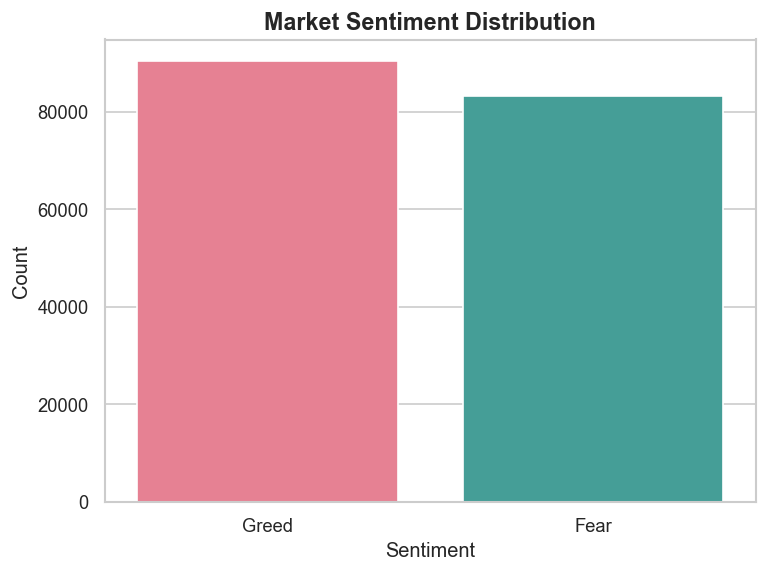

In [58]:
plt.figure(figsize=(7,5))

sns.countplot(
    x='Sentiment_Group',
    data=df,
    palette='husl'
)

plt.title("Market Sentiment Distribution", fontsize=14, weight='bold')
plt.xlabel("Sentiment")
plt.ylabel("Count")

plt.show()

# The distribution of market sentiment shows that both Greed and Fear statesoccur frequently in the dataset, 
# each with counts exceeding 80,000 observations.
# However, Greed appears slightly more dominant than Fear, 
# indicating that the market spends comparatively more time in optimistic or risk-seeking conditions

C:\Users\nitti\AppData\Local\Temp\ipykernel_13840\1684745589.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


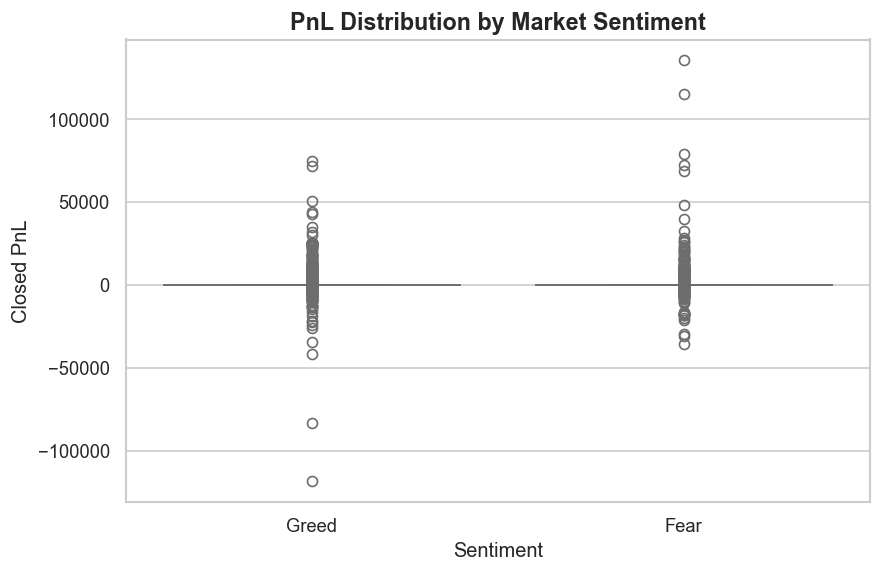

In [60]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='Sentiment_Group',
    y='Closed PnL',
    data=df,
    palette='Spectral'
)

plt.title("PnL Distribution by Market Sentiment", fontsize=14, weight='bold')
plt.xlabel("Sentiment")
plt.ylabel("Closed PnL")

plt.show()

# From the graph, we can see that trading results are spread out in both market conditions, but Fear days have more extreme outcomes. 
# Traders sometimes make very high profits, but also face bigger losses. 
# On the other hand, Greed days look more stable, with most trades staying within a smaller range.”

In [81]:
trades_per_day = df.groupby(['date', 'Sentiment_Group']).size().reset_index(name='trade_count')

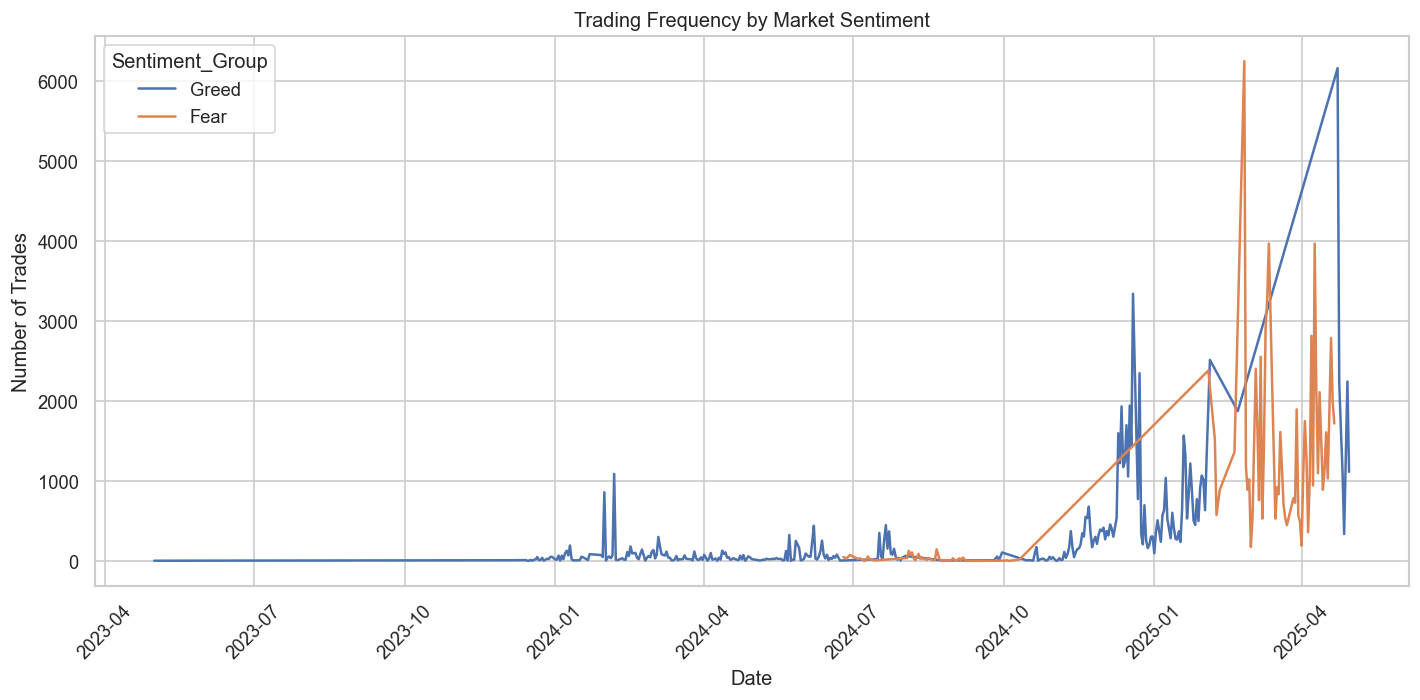

In [83]:
# Plot
plt.figure(figsize=(12,6))
sns.lineplot(data=trades_per_day, x='date', y='trade_count', hue='Sentiment_Group')

plt.title("Trading Frequency by Market Sentiment")
plt.xlabel("Date")
plt.ylabel("Number of Trades")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# From the graph, we can see that trading activity was relatively low earlier but increased sharply over time. 
# During Fear periods, there are more sudden spikes in trading, indicating panic or quick decision-making by traders.
# In contrast, Greed periods show a more gradual increase in activity, suggesting more stable and confident trading behavior.

C:\Users\nitti\AppData\Local\Temp\ipykernel_13840\72768567.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


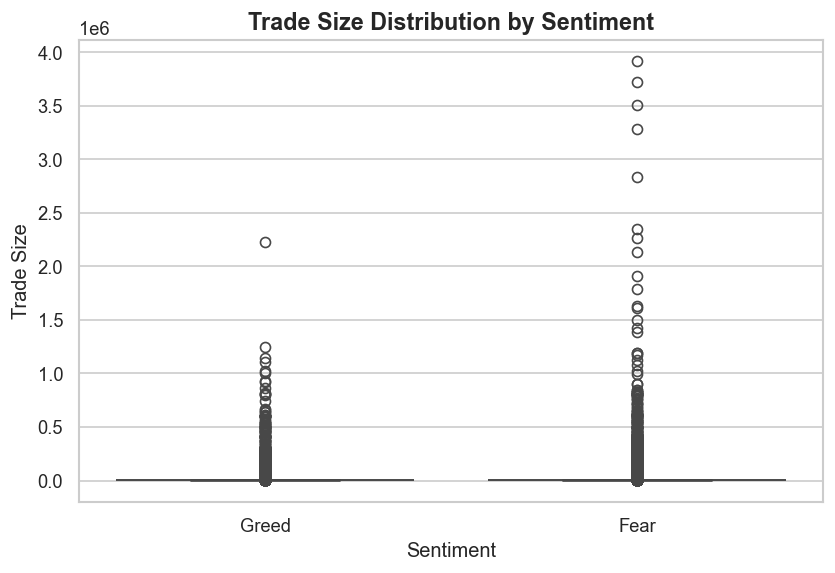

In [75]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='Sentiment_Group',
    y='Size USD',
    data=df,
    palette='Set1'
)

plt.title("Trade Size Distribution by Sentiment", fontsize=14, weight='bold')
plt.xlabel("Sentiment")
plt.ylabel("Trade Size")

plt.show()

# From the graph, we can see that most trades are small in both market conditions, but Fear periods include much larger trades compared to Greed. 
# There are more extreme values in Fear, which suggests that traders take higher risks during uncertain market conditions. 
# In contrast, Greed periods show relatively smaller and more consistent trade sizes.

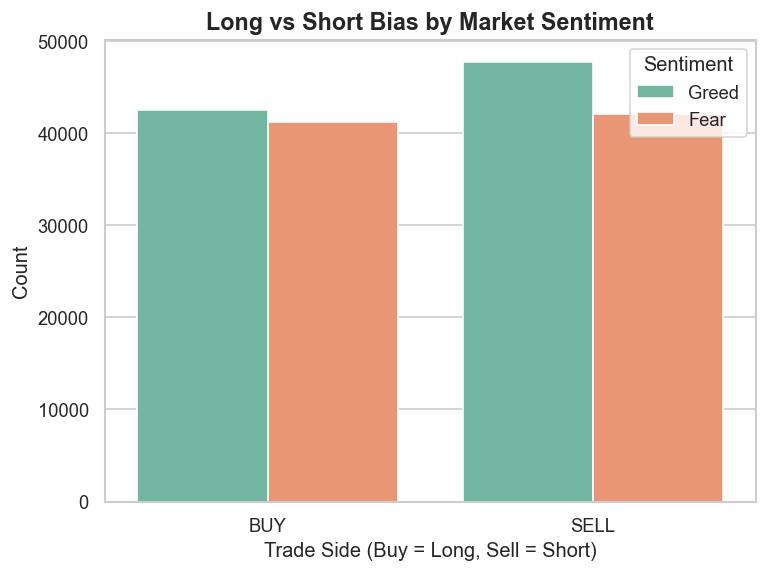

In [88]:
plt.figure(figsize=(7,5))

sns.countplot(
    x='Side',
    hue='Sentiment_Group',
    data=df,
    palette='Set2'
)

plt.title("Long vs Short Bias by Market Sentiment", fontsize=14, weight='bold')
plt.xlabel("Trade Side (Buy = Long, Sell = Short)")
plt.ylabel("Count")

plt.legend(title="Sentiment")

plt.show()

# From the graph, we can see that trading activity is slightly higher during Greed periods, with both buy and sell trades increasing. 
# Interestingly, sell trades are consistently higher than buy trades in both Greed and Fear conditions. 
# This suggests that traders may be slightly more inclined toward short positions, possibly to hedge risk or take advantage of market fluctuations

In [101]:
weekday_order = [
    'Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday'
]

df['day_name'] = pd.Categorical(df['day_name'], categories=weekday_order, ordered=True)

C:\Users\nitti\AppData\Local\Temp\ipykernel_13840\2069336453.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  daily_pnl = df.groupby('day_name')['Closed PnL'].sum().reset_index()


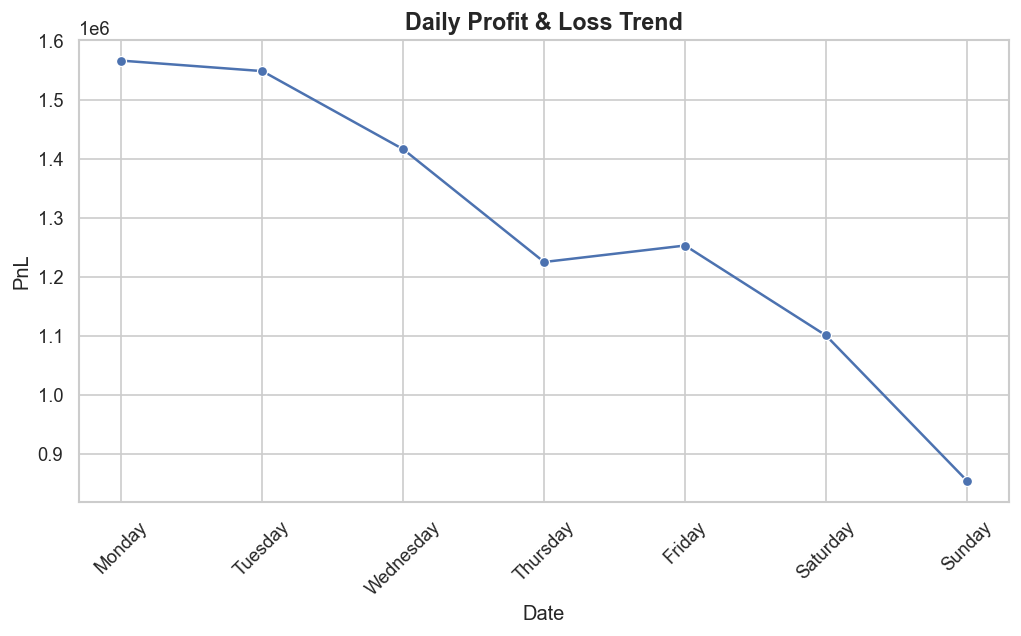

In [102]:
daily_pnl = df.groupby('day_name')['Closed PnL'].sum().reset_index()

plt.figure(figsize=(10,5))

sns.lineplot(
    x='day_name',
    y='Closed PnL',
    data=daily_pnl,
    marker='o'
)

plt.title("Daily Profit & Loss Trend", fontsize=14, weight='bold')
plt.xlabel("Date")
plt.ylabel("PnL")

plt.xticks(rotation=45)

plt.show()

# Profits are higher at the start of the week and decrease towards the weekend, with Sunday showing the lowest performance.

In [91]:
df['leverage'] = df['Size USD']

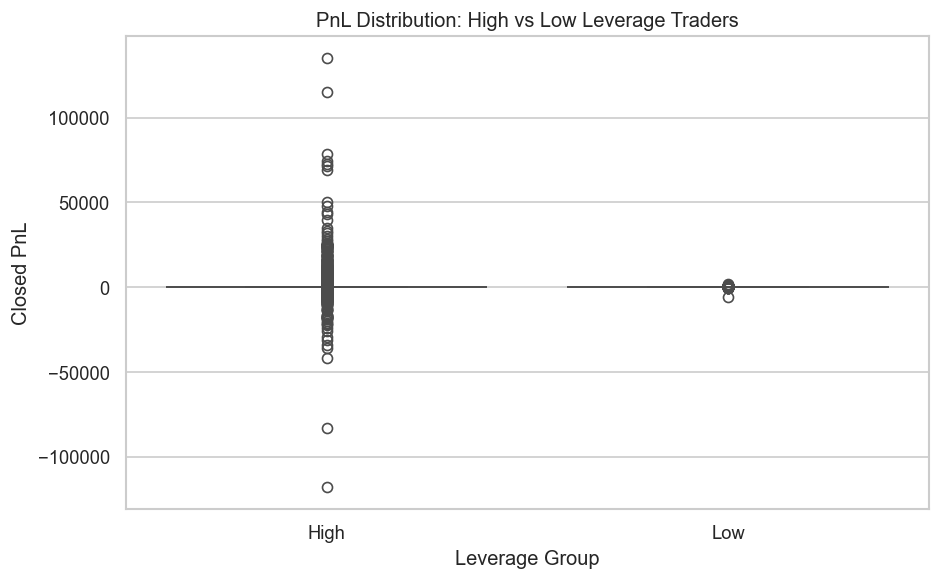

In [93]:
# Create segment
median_leverage = df['leverage'].median()
df['leverage_group'] = df['leverage'].apply(
    lambda x: 'High' if x > median_leverage else 'Low'
)

# Plot
plt.figure(figsize=(8,5))
sns.boxplot(x='leverage_group', y='Closed PnL', data=df)

plt.title("PnL Distribution: High vs Low Leverage Traders")
plt.xlabel("Leverage Group")
plt.ylabel("Closed PnL")
plt.tight_layout()
plt.show()

# From the graph, we can see that high leverage trading is associated with both higher profits and higher losses, indicating a high-risk, high-reward behavior. 
# On the other hand, low leverage traders show more controlled and stable performance with smaller fluctuations in PnL.

In [99]:
month_order = [
    'January', 'February', 'March', 'April', 'May', 'June',
    'July', 'August', 'September', 'October', 'November', 'December'
]

df['month_name'] = pd.Categorical(df['month_name'], categories=month_order, ordered=True)

C:\Users\nitti\AppData\Local\Temp\ipykernel_13840\2827721849.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  monthly_pnl = df.groupby('month_name')['Closed PnL'].mean()
C:\Users\nitti\AppData\Local\Temp\ipykernel_13840\2827721849.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


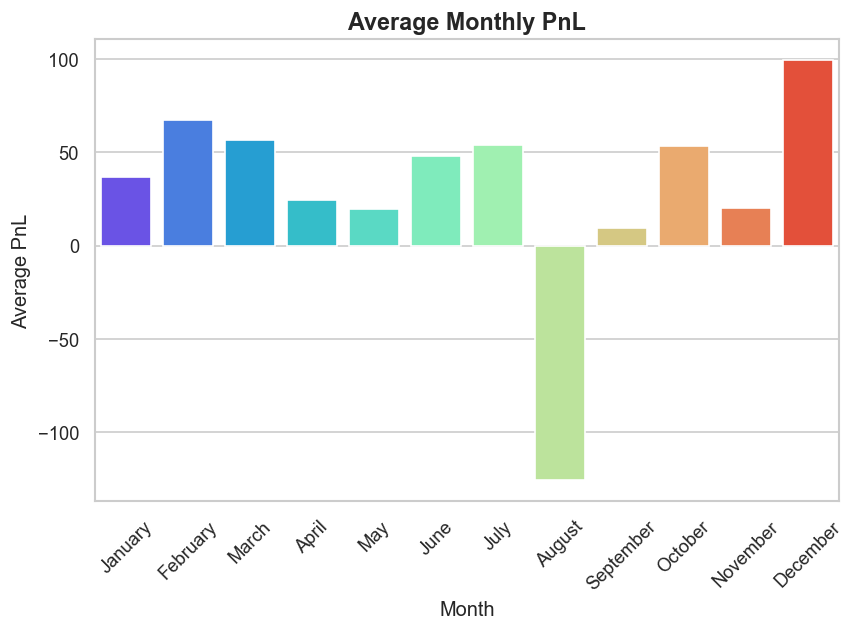

In [100]:
monthly_pnl = df.groupby('month_name')['Closed PnL'].mean()

plt.figure(figsize=(8,5))

sns.barplot(
    x=monthly_pnl.index,
    y=monthly_pnl.values,
    palette='rainbow'
)

plt.title("Average Monthly PnL", fontsize=14, weight='bold')
plt.xlabel("Month")
plt.ylabel("Average PnL")
plt.xticks(rotation=45)

plt.show()

# From the graph, we can see that trading performance is generally positive throughout the year, with peaks in February and December. 
# However, there is a sharp drop in August where the average PnL becomes negative. 
# This suggests that market conditions during August were unfavorable, but recovery happens in the following months

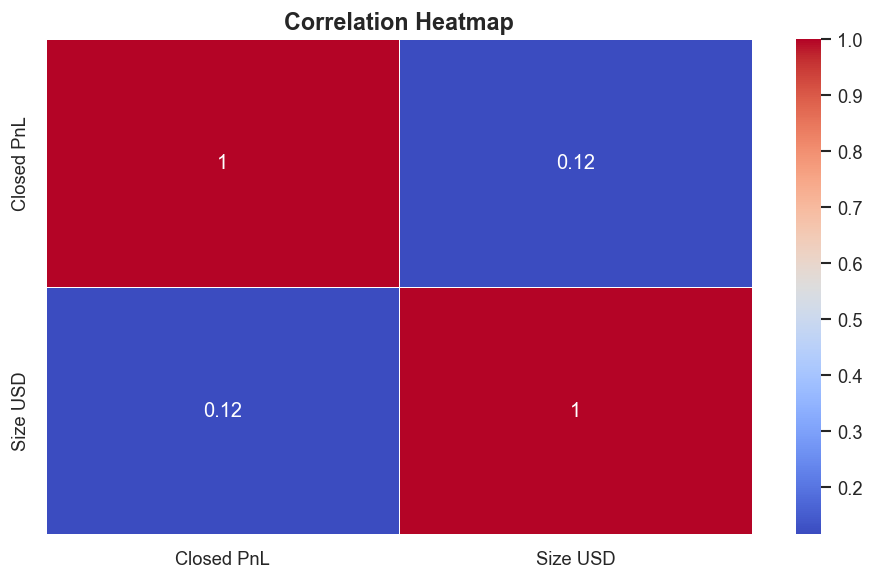

In [76]:
plt.figure(figsize=(8,5))

sns.heatmap(
    df[['Closed PnL', "Size USD"]].corr(),
    annot=True,
    cmap='coolwarm',
    linewidths=0.5
)

plt.title("Correlation Heatmap", fontsize=14, weight='bold')

plt.tight_layout()
plt.show()

# From the graph, we can see that the relationship between trade size and profit is very weak. 
# Even though larger trades might sometimes lead to higher profits, the low correlation value (0.12) 
# suggests that trade size alone is not a strong factor in determining performance

C:\Users\nitti\AppData\Local\Temp\ipykernel_13840\2761774106.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


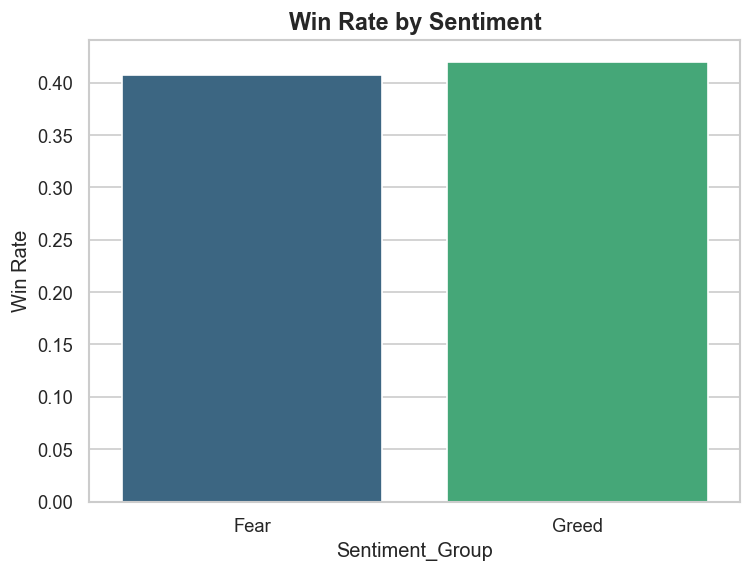

In [71]:
df['win'] = df['Closed PnL'] > 0

win_rate = df.groupby('Sentiment_Group')['win'].mean().reset_index()

plt.figure(figsize=(7,5))

sns.barplot(
    x='Sentiment_Group',
    y='win',
    data=win_rate,
    palette='viridis'
)

plt.title("Win Rate by Sentiment", fontsize=14, weight='bold')
plt.ylabel("Win Rate")

plt.show()

# From the graph, we can see that traders have a marginally higher win rate in Greed conditions.
# However, since the difference is minimal, it suggests that market sentiment alone does not strongly impact the probability of winning trades

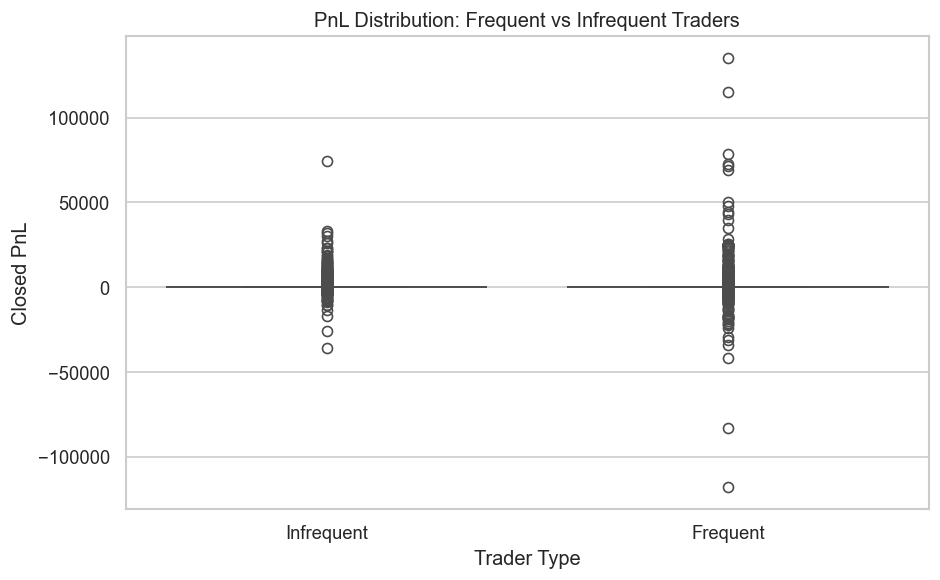

In [96]:
trader_freq = df.groupby('Account').size().reset_index(name='trade_count')
threshold = trader_freq['trade_count'].median()
trader_freq['type'] = trader_freq['trade_count'].apply(
    lambda x: 'Frequent' if x > threshold else 'Infrequent')
df = df.merge(trader_freq[['Account', 'type']], on='Account')

plt.figure(figsize=(8,5))
sns.boxplot(x='type', y='Closed PnL', data=df)

plt.title("PnL Distribution: Frequent vs Infrequent Traders")
plt.xlabel("Trader Type")
plt.ylabel("Closed PnL")
plt.tight_layout()
plt.show()

# “From the graph, we can see that frequent traders take more risks, resulting in both higher gains and higher losses. 
# In contrast, infrequent traders show more controlled performance with fewer extreme outcomes

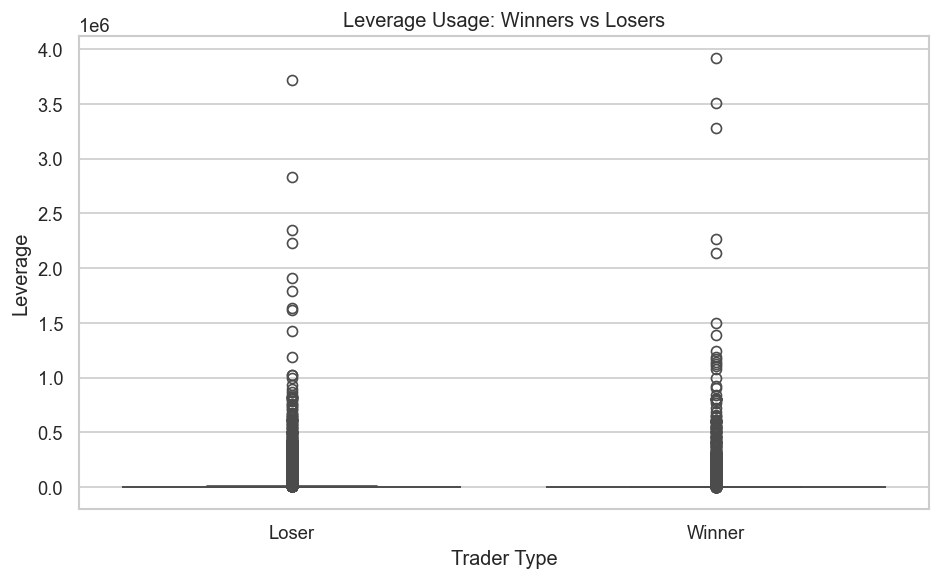

In [98]:
df['trader_type'] = df['Closed PnL'].apply(
    lambda x: 'Winner' if x > 0 else 'Loser'
)

plt.figure(figsize=(8,5))
sns.boxplot(x='trader_type', y='leverage', data=df)

plt.title("Leverage Usage: Winners vs Losers")
plt.xlabel("Trader Type")
plt.ylabel("Leverage")
plt.tight_layout()
plt.show()

# From the graph, we can see that both winning and losing traders use high leverage, and the spread of leverage values is quite similar. 
# Although some winners use higher leverage, the presence of large losses at similar levels suggests that leverage is risky and does not directly determine success

#  #### Strategy Recommendations  ""####""

# 1. Control Risk During Fear Periods

# “During Fear market conditions, traders should reduce position size and avoid taking large exposure, as the data shows higher volatility and more extreme losses.”

# 2. Avoid Over-Leveraging

# “High leverage leads to both large profits and large losses. Traders should use controlled leverage instead of maximizing it, as leverage alone does not guarantee success.”

# 3. Focus on Risk Management, Not Just Win Rate

# “Since win rate remains similar across sentiments, traders should focus on managing losses and maximizing profitable trades rather than just increasing the number of winning trades.”

#  4. Limit Over-Trading

# “Frequent traders show higher variability in PnL, indicating increased risk. Traders should avoid excessive trading and focus on quality trades instead of quantity.”

#  5. Adapt Strategy Based on Market Sentiment

# “During Greed periods, traders can take slightly higher exposure due to more stable behavior, while in Fear periods, a defensive strategy with smaller trades is more effective.”

# Successful trading depends more on risk management 
# and controlled exposure rather than high leverage, frequent trading, or simply increasing win rate.

In [104]:
df.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Start Position,Direction,Closed PnL,Order ID,...,year,month,month_name,day,day_name,leverage_proxy,leverage,leverage_group,type,trader_type
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,0.000000,Buy,0.0,52017706630,...,2024,12,December,2,Monday,7872.16,7872.16,High,Infrequent,Loser
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,986.524596,Buy,0.0,52017706630,...,2024,12,December,2,Monday,127.68,127.68,Low,Infrequent,Loser
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,1002.518996,Buy,0.0,52017706630,...,2024,12,December,2,Monday,1150.63,1150.63,High,Infrequent,Loser
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,1146.558564,Buy,0.0,52017706630,...,2024,12,December,2,Monday,1142.04,1142.04,High,Infrequent,Loser
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,1289.488521,Buy,0.0,52017706630,...,2024,12,December,2,Monday,69.75,69.75,Low,Infrequent,Loser


In [105]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 173532 entries, 0 to 173531
Data columns (total 29 columns):
 #   Column           Non-Null Count   Dtype         
---  ------           --------------   -----         
 0   Account          173532 non-null  object        
 1   Coin             173532 non-null  object        
 2   Execution Price  173532 non-null  float64       
 3   Size Tokens      173532 non-null  float64       
 4   Size USD         173532 non-null  float64       
 5   Side             173532 non-null  object        
 6   Start Position   173532 non-null  float64       
 7   Direction        173532 non-null  object        
 8   Closed PnL       173532 non-null  float64       
 9   Order ID         173532 non-null  int64         
 10  Crossed          173532 non-null  bool          
 11  Fee              173532 non-null  float64       
 12  Trade ID         173532 non-null  float64       
 13  Timestamp        173532 non-null  float64       
 14  date             173

In [106]:
df.drop("date",axis=1,inplace=True)

In [107]:
df["Crossed"]=df["Crossed"].astype(int)
df["win"]=df["win"].astype(int)

In [108]:
categorical= df.select_dtypes(include="object")
numerical=df.select_dtypes(exclude="object")

In [109]:
le=LabelEncoder()

In [110]:
for i in categorical:
    df[i]=le.fit_transform(df[i])

In [111]:
df.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Start Position,Direction,Closed PnL,Order ID,...,year,month,month_name,day,day_name,leverage_proxy,leverage,leverage_group,type,trader_type
0,25,4,7.9769,986.87,7872.16,0,0.000000,1,0.0,52017706630,...,2024,12,December,2,Monday,7872.16,7872.16,0,1,0
1,25,4,7.9800,16.00,127.68,0,986.524596,1,0.0,52017706630,...,2024,12,December,2,Monday,127.68,127.68,1,1,0
2,25,4,7.9855,144.09,1150.63,0,1002.518996,1,0.0,52017706630,...,2024,12,December,2,Monday,1150.63,1150.63,0,1,0
3,25,4,7.9874,142.98,1142.04,0,1146.558564,1,0.0,52017706630,...,2024,12,December,2,Monday,1142.04,1142.04,0,1,0
4,25,4,7.9894,8.73,69.75,0,1289.488521,1,0.0,52017706630,...,2024,12,December,2,Monday,69.75,69.75,1,1,0


In [112]:
z=np.abs(zscore(df))
df1=df[(z<3).all(axis=1)]

TypeError: unsupported operand type(s) for /: 'str' and 'int'

In [ ]:
df1.shape

In [ ]:
df.shape

In [ ]:
df=df1.copy()

In [ ]:
df.head()

In [ ]:
df.skew()

In [ ]:
skew=["Execution Price","Size Tokens","Size USD","Start Position","Closed PnL","Order ID","Fee","Timestamp"]
skewness=PowerTransformer(method="yeo-johnson")
df[skew]=skewness.fit_transform(df[skew])

In [ ]:
df.skew()

In [ ]:
x=df.drop("Sentiment_Group",axis=1)
y=df["Sentiment_Group"]

In [ ]:
sc=StandardScaler()

In [ ]:
x_sc=sc.fit_transform(x)

In [ ]:
maxAccu=0
maxRs=0
for i in range(1,250):
    X_train,X_test,y_train,y_test=train_test_split(x_sc,y,test_size=0.3,random_state=i)
    log_reg=LogisticRegression()
    log_reg.fit(X_train,y_train)
    y_pred=log_reg.predict(X_test)
    acc=accuracy_score(y_test,y_pred)
    if acc>maxAccu:
        maxAccu=acc
        maxRs=i
print("Best Accuracy is",maxAccu,"on Random_state",maxRs)

In [ ]:
X_train,X_test,y_train,y_test=train_test_split(x_sc,y,random_state=1,test_size=0.3)
log=LogisticRegression()
log.fit(X_train,y_train)
y_pred=log.predict(X_test)
print(classification_report(y_pred,y_test))

In [ ]:
maxAccu=0
maxRs=0
for i in range(1,250):
    X_train,X_test,y_train,y_test=train_test_split(x_sc,y,test_size=0.3,random_state=i)
    Dtc=DecisionTreeClassifier()
    Dtc.fit(X_train,y_train)
    y_pred=Dtc.predict(X_test)
    acc=accuracy_score(y_test,y_pred)
    if acc>maxAccu:
        maxAccu=acc
        maxRs=i
print("Best Accuracy is",maxAccu,"on Random_state",maxRs)

In [ ]:
X_train,X_test,y_train,y_test=train_test_split(x_sc,y,random_state=1,test_size=0.3)
Dtc=DecisionTreeClassifier()
Dtc.fit(X_train,y_train)
y_pred=Dtc.predict(X_test)
print(classification_report(y_pred,y_test))

In [ ]:
X_train,X_test,y_train,y_test=train_test_split(x_sc,y,random_state=1,test_size=0.3)
knn=KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train,y_train)
y_pred=knn.predict(X_test)
print(classification_report(y_pred,y_test))

In [ ]:
Rc=RandomForestClassifier(n_estimators=10,criterion="entropy",random_state=48)
Rc.fit(x_train,y_train)
y_pred=Rc.predict(x_test)
print(classification_report(y_test,y_pred))